In [1]:
"""
Flujo de trabajo de segmentación de imágenes científicas
Este notebook integra las principales herramientas de segmentación presentadas hasta ahora en un flujo de trabajo completo de análisis de imágenes.
En lugar de estudiar por separado el threshold, la morphology, los componentes conectados y las mediciones de región, ahora los combinamos en un flujo de trabajo práctico que comienza con una imagen en escala de grises y termina con un análisis cuantitativo basado en objetos.
Objetivos de aprendizaje
- Construir un workflow de segmentación completo
- Aplicar el threshold, la morphology y el análisis de componentes conectados de forma secuencial
- Medir cuantitativamente los objetos segmentados
- Visualizar los resultados intermedios y finales del workflow
- Comprender la segmentación como un proceso de análisis reproducible
Contexto de la imagen reales
En la imagen reales, la segmentación rara vez es una sola operación. Generalmente es un workflow compuesto por:
- Preparación de la imagen
- Segmentación inicial
- Limpieza de la máscara
- Separación de objetos
- Medición cuantitativa
Este cuaderno muestra cómo estas etapas funcionan juntas de forma reproducible.
"""

'\nFlujo de trabajo de segmentación de imágenes científicas\nEste notebook integra las principales herramientas de segmentación presentadas hasta ahora en un flujo de trabajo completo de análisis de imágenes.\nEn lugar de estudiar por separado el threshold, la morphology, los componentes conectados y las mediciones de región, ahora los combinamos en un flujo de trabajo práctico que comienza con una imagen en escala de grises y termina con un análisis cuantitativo basado en objetos.\nObjetivos de aprendizaje\n- Construir un workflow de segmentación completo\n- Aplicar el threshold, la morphology y el análisis de componentes conectados de forma secuencial\n- Medir cuantitativamente los objetos segmentados\n- Visualizar los resultados intermedios y finales del workflow\n- Comprender la segmentación como un proceso de análisis reproducible\nContexto de la imagen reales\nEn la imagen reales, la segmentación rara vez es una sola operación. Generalmente es un workflow compuesto por:\n- Prepar

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import data, filters, morphology, measure, color, segmentation, util

In [3]:
def show_image(image, title="", cmap="gray", save_path=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def compare_images(images, titles, cmap="gray", figsize=(15, 5), save_path=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def save_dataframe_csv(df, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)

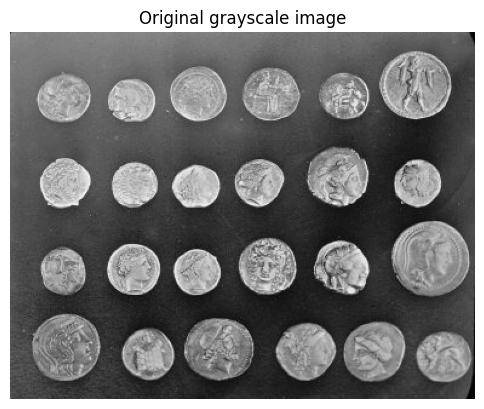

In [4]:
"""
Imagen de entrada
Partimos de una imagen real en escala de grises. En este notebook, usamos el ejemplo de las monedas porque contiene varios objetos de diferentes tamaños y algunos bordes que se tocan, lo que resulta útil para demostrar un flujo de trabajo de segmentación completo.
"""
image = data.coins()

show_image(
    image,
    "Original grayscale image",
    save_path="../figures/figures_segmantation_pipeline/01_original_image.png"
)

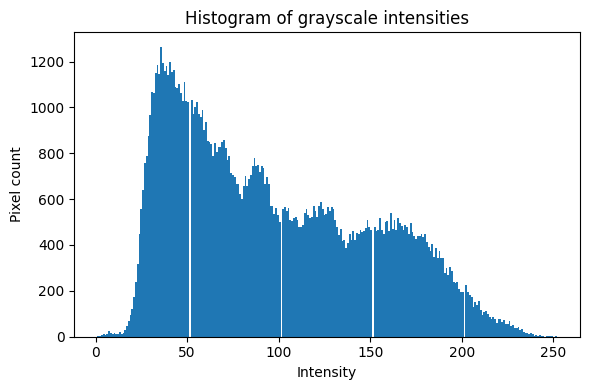

In [5]:
"""
Histograma de la imagen
Antes de aplicar el umbral, es útil inspeccionar la distribución de intensidad de la escala de grises.
"""
plt.figure(figsize=(6, 4))
plt.hist(image.ravel(), bins=256)
plt.title("Histogram of grayscale intensities")
plt.xlabel("Intensity")
plt.ylabel("Pixel count")
plt.tight_layout()

plt.savefig(
    "../figures/figures_segmantation_pipeline/02_histogram.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

Otsu threshold: 107.00


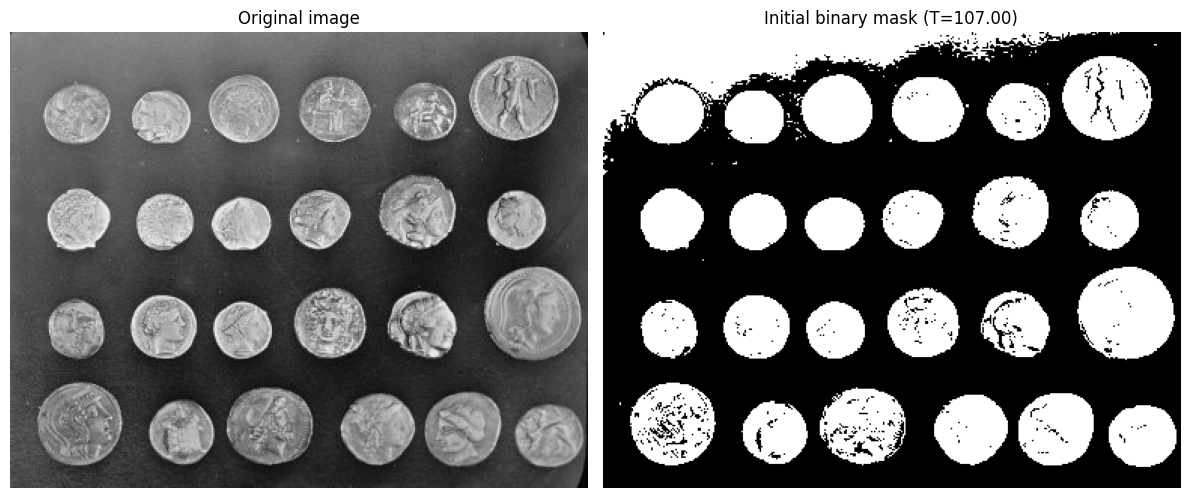

In [6]:
"""
Thresholding
Usaremos el metodo Otsu  para generar la mascara inicial desde la imagen inicial en la escala de grises
"""
threshold = filters.threshold_otsu(image)
binary_mask = image > threshold

print(f"Otsu threshold: {threshold:.2f}")

compare_images(
    [image, binary_mask],
    ["Original image", f"Initial binary mask (T={threshold:.2f})"],
    figsize=(12, 5),
    save_path="../figures/figures_segmantation_pipeline/03_thresholding_result.png"
)

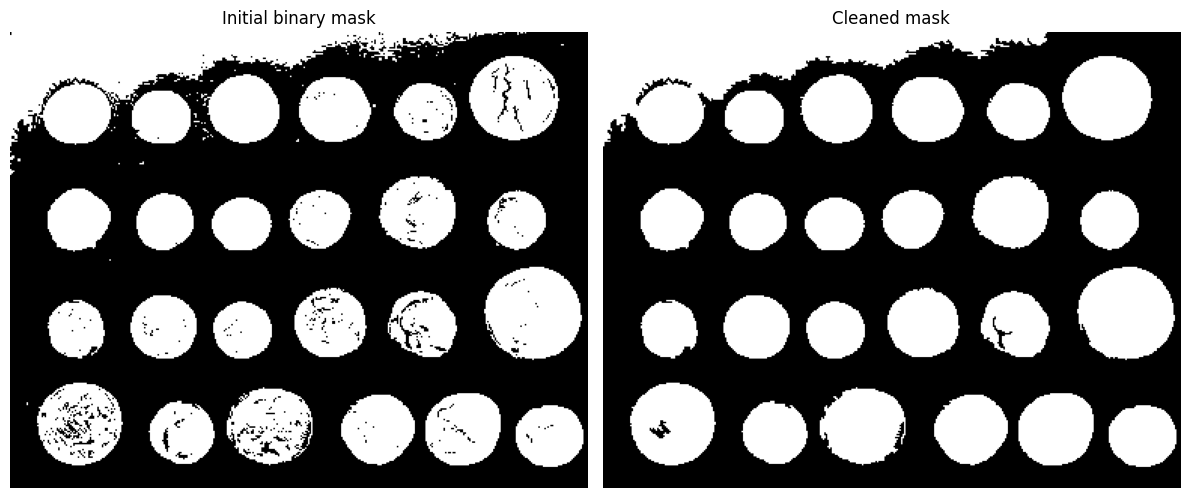

In [22]:
"""
Morphology clean up
La máscara thresholding inicial puede contener pequeñas regiones ruidosas, agujeros o bordes irregulares.
Aplicamos:
- remove_small_objects para suprimir pequeñas regiones en primer plano
- remove_small_holes para rellenar pequeños agujeros dentro de los objetos segmentados
"""
clean_mask = morphology.remove_small_objects(binary_mask, max_size=107)
clean_mask = morphology.remove_small_holes(clean_mask, max_size=50)

compare_images(
    [binary_mask, clean_mask],
    ["Initial binary mask", "Cleaned mask"],
    figsize=(12, 5),
    save_path="../figures/figures_segmantation_pipeline/04_mask_cleanup.png"
)

Number of labeled regions: 24


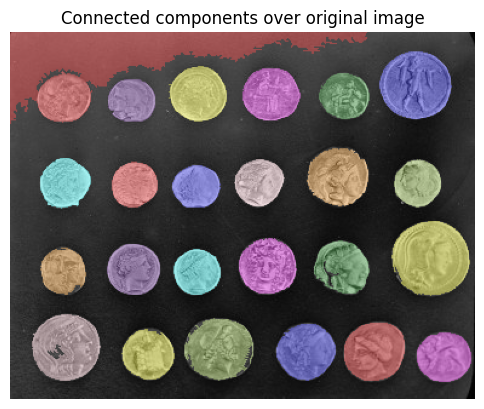

In [23]:
"""
Etiquedato de componentes concetados
Una vez que la mascara esta limpia, definimos las conecciones individuales
"""
labels = measure.label(clean_mask, connectivity=2)

print(f"Number of labeled regions: {labels.max()}")

show_image(
    color.label2rgb(labels, image=image, bg_label=0),
    "Connected components over original image",
    cmap=None,
    save_path="../figures/figures_segmantation_pipeline/05_labeled_regions_overlay.png"
)

In [24]:
"""
Propiedades de la región
Ahora extraemos propiedades cuantitativas de cada región etiquetada.
Este paso convierte el resultado de la segmentación en un conjunto de datos estructurado que puede analizarse estadísticamente o utilizarse como entrada para el aprendizaje automático.
"""
props_table = measure.regionprops_table(
    labels,
    intensity_image=image,
    properties=[
        "label",
        "area",
        "centroid",
        "bbox",
        "equivalent_diameter",
        "eccentricity",
        "perimeter",
        "solidity",
        "mean_intensity"
    ]
)

df_props = pd.DataFrame(props_table)
df_props.head()

,label,area,centroid-0,centroid-1,bbox-0,bbox-1,bbox-2,bbox-3,equivalent_diameter,eccentricity,perimeter,solidity,mean_intensity
0,1,8897.0,22.738564,91.727436,0,0,76,295,106.433135,0.976567,1046.133080,0.643172,126.686636
1,2,2606.0,43.457790,334.597467,16,305,72,365,57.602624,0.329421,188.752309,0.982284,156.831159
2,3,1684.0,50.766033,155.141924,28,131,74,179,46.304810,0.295118,154.160426,0.967816,168.416865
3,4,1639.0,51.021965,215.142160,30,192,73,240,45.681940,0.388589,150.124892,0.980850,157.239780
4,5,1232.0,52.424513,275.986201,34,255,72,297,39.605948,0.409037,132.225397,0.973144,154.126623


In [25]:
save_dataframe_csv(
    df_props,
    "../figures/figures_segmantation_pipeline/region_properties.csv"
)

In [ ]:
"""
Visualización de centroides y cuadros delimitadores
Para interpretar mejor la segmentación, visualizamos cada región conectada junto con su centroide y cuadro delimitador.
"""
regions = measure.regionprops(labels, intensity_image=image)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image, cmap="gray")
ax.set_title("Segmented objects with centroids and bounding boxes")
ax.axis("off")

for region in regions:
    minr, minc, maxr, maxc = region.bbox
    y0, x0 = region.centroid

    rect = plt.Rectangle(
        (minc, minr),
        maxc - minc,
        maxr - minr,
        fill=False,
        edgecolor="red",
        linewidth=1.5
    )
    ax.add_patch(rect)
    ax.plot(x0, y0, "bo", markersize=3)
    ax.text(x0 + 2, y0, str(region.label), color="yellow", fontsize=8)

plt.tight_layout()
os.makedirs("../figures/figures_segmantation_pipeline", exist_ok=True)
plt.savefig(
    "../figures/figures_segmantation_pipeline/06_bboxes_centroids.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()